# Individual Federated Runs: Baseline + Sweep Summary

This notebook compares the baseline individual run against each sweep run. For every
sweep run, it renders a grid of benchmark plots that compare centralized vs fedavg vs
bank_perclient for **baseline vs that run**. The final section ranks runs by
bank_perclient - fedavg (and reports other deltas for context).


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

sns.set_theme(style="whitegrid")

ROOT = Path('.').resolve()
NORMAL_RESULT_ROOT = ROOT / 'individual_results'
NORMAL_LOG_ROOT = ROOT / 'individual_logs'
SHARDED_RESULT_ROOT = ROOT / 'individual_sharded_results'
SHARDED_LOG_ROOT = ROOT / 'individual_sharded_logs'
SWEEP_LOG_ROOT = ROOT / 'individual_sweep_logs'

# Update this if the baseline id changes.
BASELINE_RUN_ID = 'individual_local_20260115_100457_21987'


# Set to override the most recent multi-client (sharded) run.
LATEST_SHARDED_RUN_ID = None

SWEEP_ID = None

EXPS = ['centralized', 'fedavg', 'bank_perclient']
BENCHES = ['gsm8k', 'hellaswag', 'piqa', 'xsum', 'hotpotqa', 'mbpp', 'apps', 'toolbench']


def _latest_run_id(root, prefix=None, exclude_prefixes=None):
    if not root.exists():
        return None
    runs = [p for p in root.iterdir() if p.is_dir()]
    if prefix:
        runs = [p for p in runs if p.name.startswith(prefix)]
    if exclude_prefixes:
        runs = [p for p in runs if not any(p.name.startswith(x) for x in exclude_prefixes)]
    if not runs:
        return None
    runs.sort(key=lambda p: p.stat().st_mtime)
    return runs[-1].name


def _find_config(run_root, exp):
    base = run_root / exp / 'train'
    if not base.exists():
        return None
    candidates = [p for p in base.glob('**/config.yaml') if 'wandb' not in p.parts]
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime)
    return candidates[-1]


def _get(cfg, keys):
    cur = cfg
    for key in keys:
        if cur is None:
            return None
        cur = cur.get(key)
    return cur


def collect_hparams(run_tag, run_id, run_root):
    rows = []
    for exp in EXPS:
        cfg_path = _find_config(run_root, exp)
        if cfg_path is None:
            rows.append({
                'run_tag': run_tag,
                'run_id': run_id,
                'exp': exp,
                'config_path': None,
            })
            continue
        cfg = yaml.safe_load(cfg_path.read_text())
        rows.append({
            'run_tag': run_tag,
            'run_id': run_id,
            'exp': exp,
            'total_round_num': _get(cfg, ['federate', 'total_round_num']),
            'sample_client_rate': _get(cfg, ['federate', 'sample_client_rate']),
            'sample_client_num': _get(cfg, ['federate', 'sample_client_num']),
            'client_num': _get(cfg, ['federate', 'client_num']),
            'local_update_steps': _get(cfg, ['train', 'local_update_steps']),
            'lr': _get(cfg, ['train', 'optimizer', 'lr']),
            'merge_clients': _get(cfg, ['data', 'tulu3_federated', 'merge_clients']),
            'sharding_enable': _get(cfg, ['data', 'tulu3_federated', 'sharding', 'enable']),
            'sharding_default': _get(cfg, ['data', 'tulu3_federated', 'sharding', 'default_shards']),
            'config_path': str(cfg_path),
        })
    return rows


def _find_accuracy_file(run_root, exp, bench):
    base = run_root / 'global' / exp / bench
    if not base.exists():
        return None
    candidates = list(base.glob(f'**/eval_result/accuracies_*__{bench}.json'))
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime)
    return candidates[-1]


def _parse_metric(data, bench):
    if bench in {'gsm8k', 'hellaswag', 'piqa'}:
        val = data.get('weighted_accuracy')
        if val is None and bench == 'gsm8k':
            val = data.get('categories', {}).get('gsm8k')
        return 'weighted_accuracy', val
    if bench == 'xsum':
        return 'rougeL_f1', data.get('rougeL_f1')
    if bench == 'hotpotqa':
        return 'f1', data.get('f1')
    if bench in {'mbpp', 'apps'}:
        return 'pass@1', data.get('pass@1')
    if bench == 'toolbench':
        val = data.get('score')
        if val is None:
            for key in ('overall', 'overall_score', 'success_rate'):
                if key in data:
                    val = data[key]
                    break
        return 'score', val
    return None, None


def collect_results_df(run_tag, run_root):
    rows = []
    for exp in EXPS:
        for bench in BENCHES:
            path = _find_accuracy_file(run_root, exp, bench)
            if path is None:
                rows.append({
                    'run_tag': run_tag,
                    'exp': exp,
                    'benchmark': bench,
                    'metric': None,
                    'value': None,
                    'error': 'missing',
                    'result_path': None,
                })
                continue
            data = json.loads(path.read_text())
            metric, value = _parse_metric(data, bench)
            rows.append({
                'run_tag': run_tag,
                'exp': exp,
                'benchmark': bench,
                'metric': metric,
                'value': value,
                'error': data.get('error'),
                'result_path': str(path),
            })
    return pd.DataFrame(rows)


def plot_run_grid(baseline_df, run_df, run_label, run_meta, cols=3):
    combined = pd.concat([
        baseline_df.assign(run='baseline'),
        run_df.assign(run=run_label),
    ], ignore_index=True)
    rows = (len(BENCHES) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.6))
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for idx, bench in enumerate(BENCHES):
        ax = axes[idx]
        subset = combined[combined['benchmark'] == bench].copy()
        if subset['value'].notna().sum() == 0:
            ax.set_axis_off()
            continue
        sns.barplot(data=subset, x='exp', y='value', hue='run', order=EXPS, ax=ax)
        metric = subset['metric'].dropna().iloc[0] if not subset['metric'].dropna().empty else 'metric'
        ax.set_title(bench)
        ax.set_xlabel('')
        ax.set_ylabel(metric)
        if idx == 0:
            ax.legend(fontsize='small')
        else:
            ax.get_legend().remove()
    for j in range(len(BENCHES), len(axes)):
        axes[j].set_axis_off()
    fig.suptitle(f'Baseline vs {run_label} ({run_meta})', fontsize=12)
    fig.tight_layout()
    plt.show()


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
baseline_root = NORMAL_RESULT_ROOT / BASELINE_RUN_ID
if not baseline_root.exists():
    raise FileNotFoundError(f'Baseline run not found: {baseline_root}')

baseline_df = collect_results_df('baseline', baseline_root)

if SWEEP_ID is None:
    SWEEP_ID = _latest_run_id(SWEEP_LOG_ROOT)

print('BASELINE_RUN_ID:', BASELINE_RUN_ID)
print('SWEEP_ID:', SWEEP_ID)


BASELINE_RUN_ID: individual_local_20260115_100457_21987
SWEEP_ID: individual_sweep_20260116_145112_21398


In [ ]:
if LATEST_SHARDED_RUN_ID is None:
    LATEST_SHARDED_RUN_ID = _latest_run_id(SHARDED_RESULT_ROOT, prefix='individual_sharded_')

if LATEST_SHARDED_RUN_ID is None:
    print('No sharded runs found in individual_sharded_results.')
else:
    sharded_root = SHARDED_RESULT_ROOT / LATEST_SHARDED_RUN_ID
    print('LATEST_SHARDED_RUN_ID:', LATEST_SHARDED_RUN_ID)
    sharded_df = collect_results_df('latest_sharded', sharded_root)
    plot_run_grid(baseline_df, sharded_df, 'latest_sharded', f'id={LATEST_SHARDED_RUN_ID}')
    display(sharded_df[sharded_df['value'].notna()].sort_values(['benchmark','exp']))


## Hyperparameters (Baseline + Sweep Runs)


In [3]:
if SWEEP_ID is None:
    print('No sweep runs found in individual_sweep_logs.')
else:
    sweep_dir = SWEEP_LOG_ROOT / SWEEP_ID
    runs_path = sweep_dir / 'runs.tsv'
    if not runs_path.exists():
        print(f'Missing runs.tsv in {sweep_dir}')
    else:
        sweep_runs = pd.read_csv(runs_path, sep='	')
        display(sweep_runs)

        hparam_rows = []
        hparam_rows.extend(collect_hparams('baseline', BASELINE_RUN_ID, baseline_root))
        for row in sweep_runs.itertuples(index=False):
            run_root = (SHARDED_RESULT_ROOT if row.mode == 'sharded' else NORMAL_RESULT_ROOT) / row.run_id
            run_tag = f"{row.run_tag} ({row.mode})"
            if not run_root.exists():
                print(f"Missing results dir for {run_tag}: {run_root}")
                continue
            hparam_rows.extend(collect_hparams(run_tag, row.run_id, run_root))

        hparams_df = pd.DataFrame(hparam_rows)
        if not hparams_df.empty:
            display(hparams_df)
        else:
            print('No hyperparameters found.')


,run_tag,mode,run_id,cfg_prefix,script
0,participation,normal,individual_sweep_20260116_145112_21398_partici...,individual_federated_participation,run_local_individual_sweep_pipeline.sh
1,budget,normal,individual_sweep_20260116_145112_21398_budget,individual_federated_budget,run_local_individual_sweep_pipeline.sh
2,sharded_light,sharded,individual_sweep_20260116_145112_21398_sharded...,individual_federated_sharded_light,run_local_individual_sweep_pipeline.sh


,run_tag,run_id,exp,total_round_num,sample_client_rate,sample_client_num,client_num,local_update_steps,lr,merge_clients,sharding_enable,sharding_default,config_path
0,baseline,individual_local_20260115_100457_21987,centralized,60,-1.0,1,1,75,0.00002,True,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
1,baseline,individual_local_20260115_100457_21987,fedavg,60,1.0,5,5,250,0.00020,False,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
2,baseline,individual_local_20260115_100457_21987,bank_perclient,60,1.0,5,5,250,0.00020,False,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
3,participation (normal),individual_sweep_20260116_145112_21398_partici...,centralized,60,-1.0,1,1,75,0.00002,True,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
4,participation (normal),individual_sweep_20260116_145112_21398_partici...,fedavg,60,0.6,3,5,250,0.00020,False,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
5,participation (normal),individual_sweep_20260116_145112_21398_partici...,bank_perclient,60,0.6,3,5,250,0.00020,False,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
6,budget (normal),individual_sweep_20260116_145112_21398_budget,centralized,40,-1.0,1,1,75,0.00002,True,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
7,budget (normal),individual_sweep_20260116_145112_21398_budget,fedavg,40,0.6,3,5,375,0.00020,False,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
8,budget (normal),individual_sweep_20260116_145112_21398_budget,bank_perclient,40,0.6,3,5,375,0.00020,False,False,1,/home/heck2/sbhansali8/FTL/individual_results/...
9,sharded_light (sharded),individual_sweep_20260116_145112_21398_sharded...,centralized,80,-1.0,1,1,100,0.00002,True,False,1,/home/heck2/sbhansali8/FTL/individual_sharded_...


## Sweep Run Grids (Baseline vs Each Run)


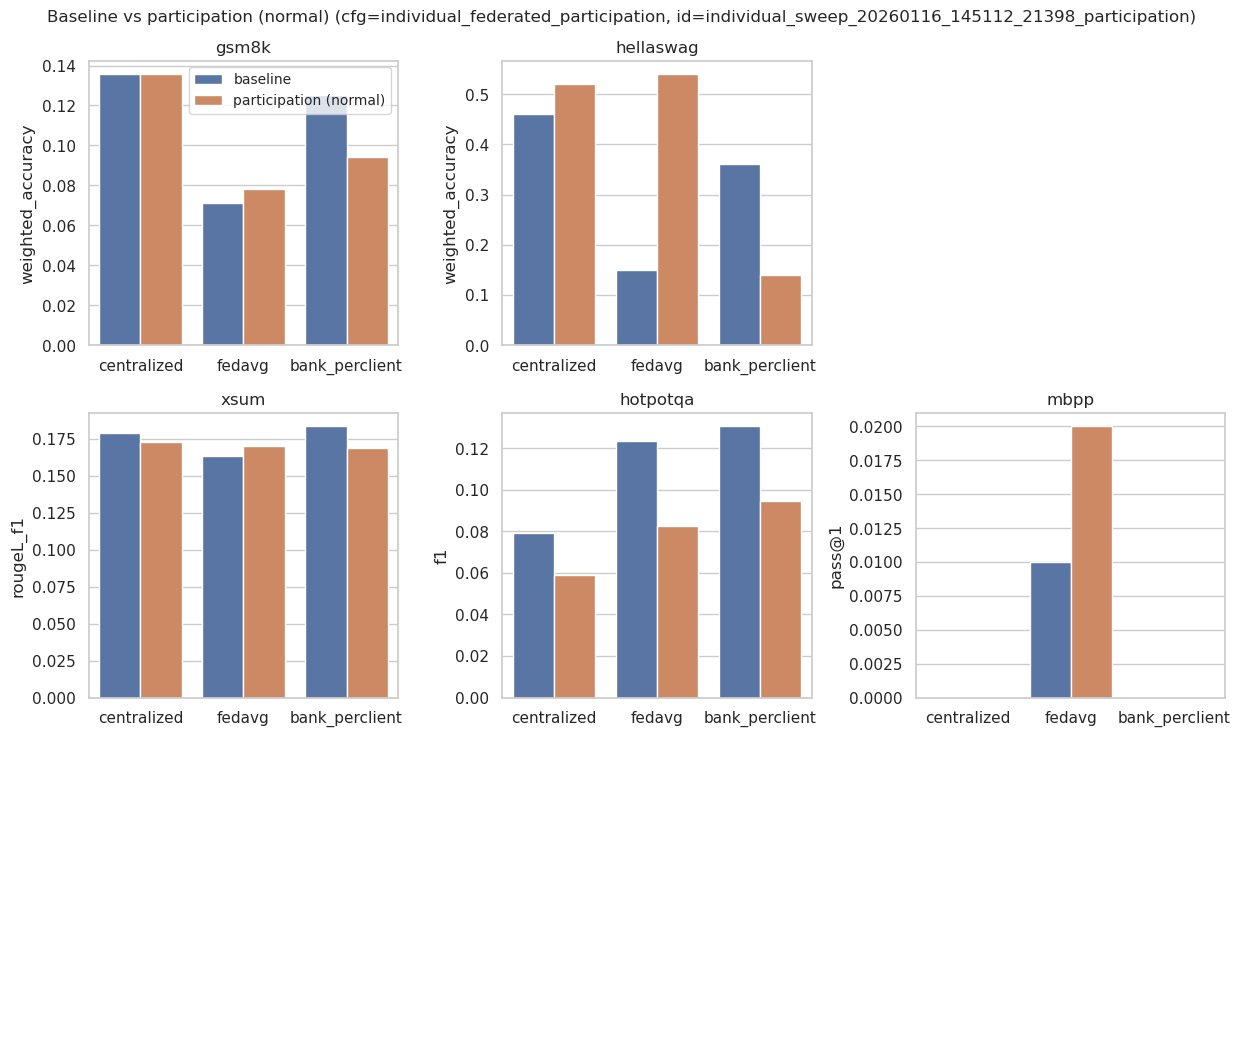

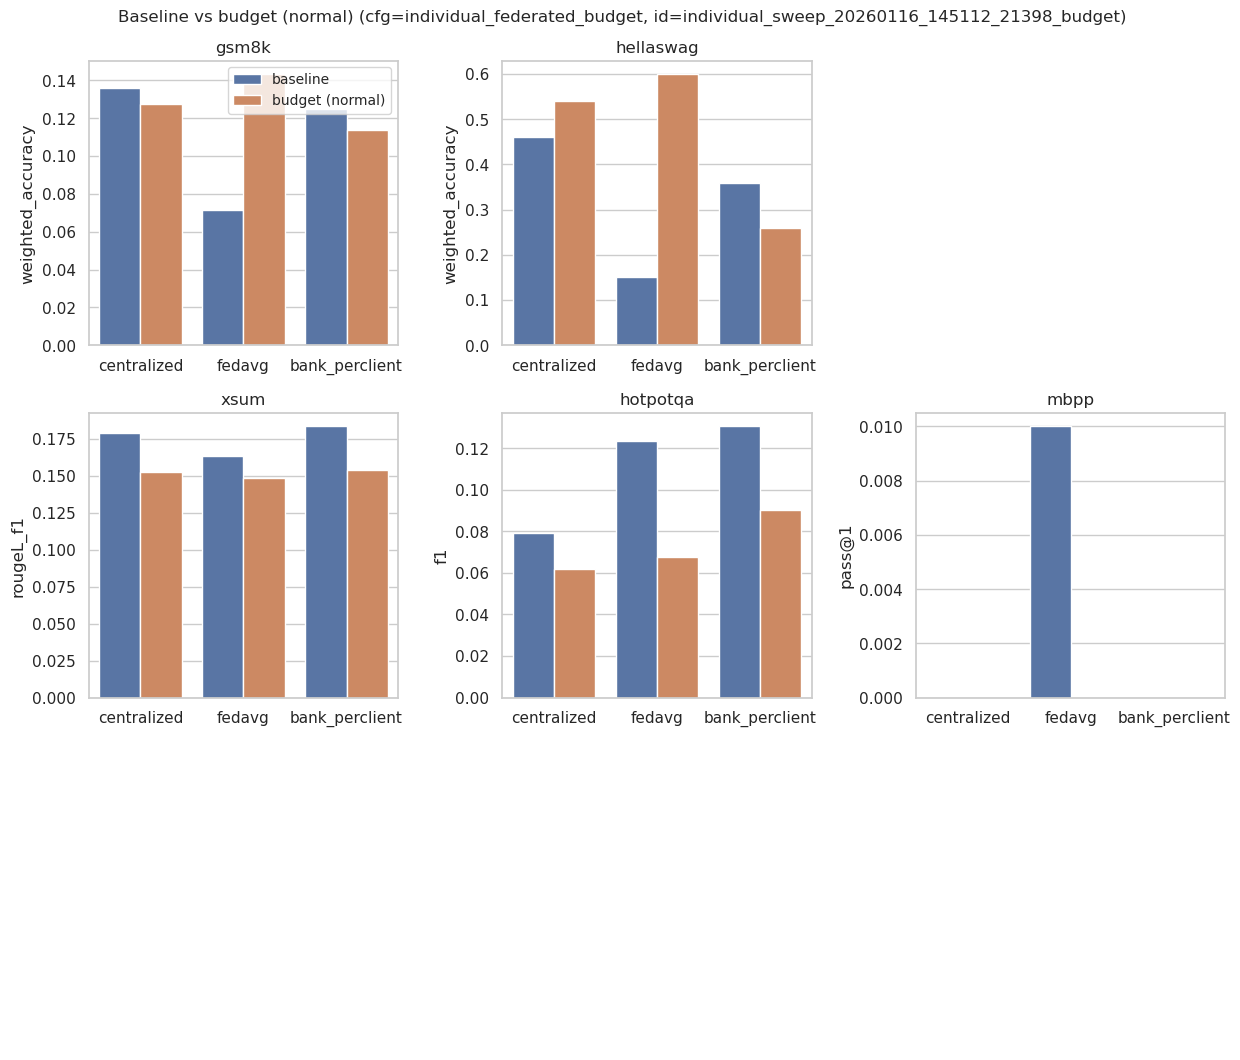

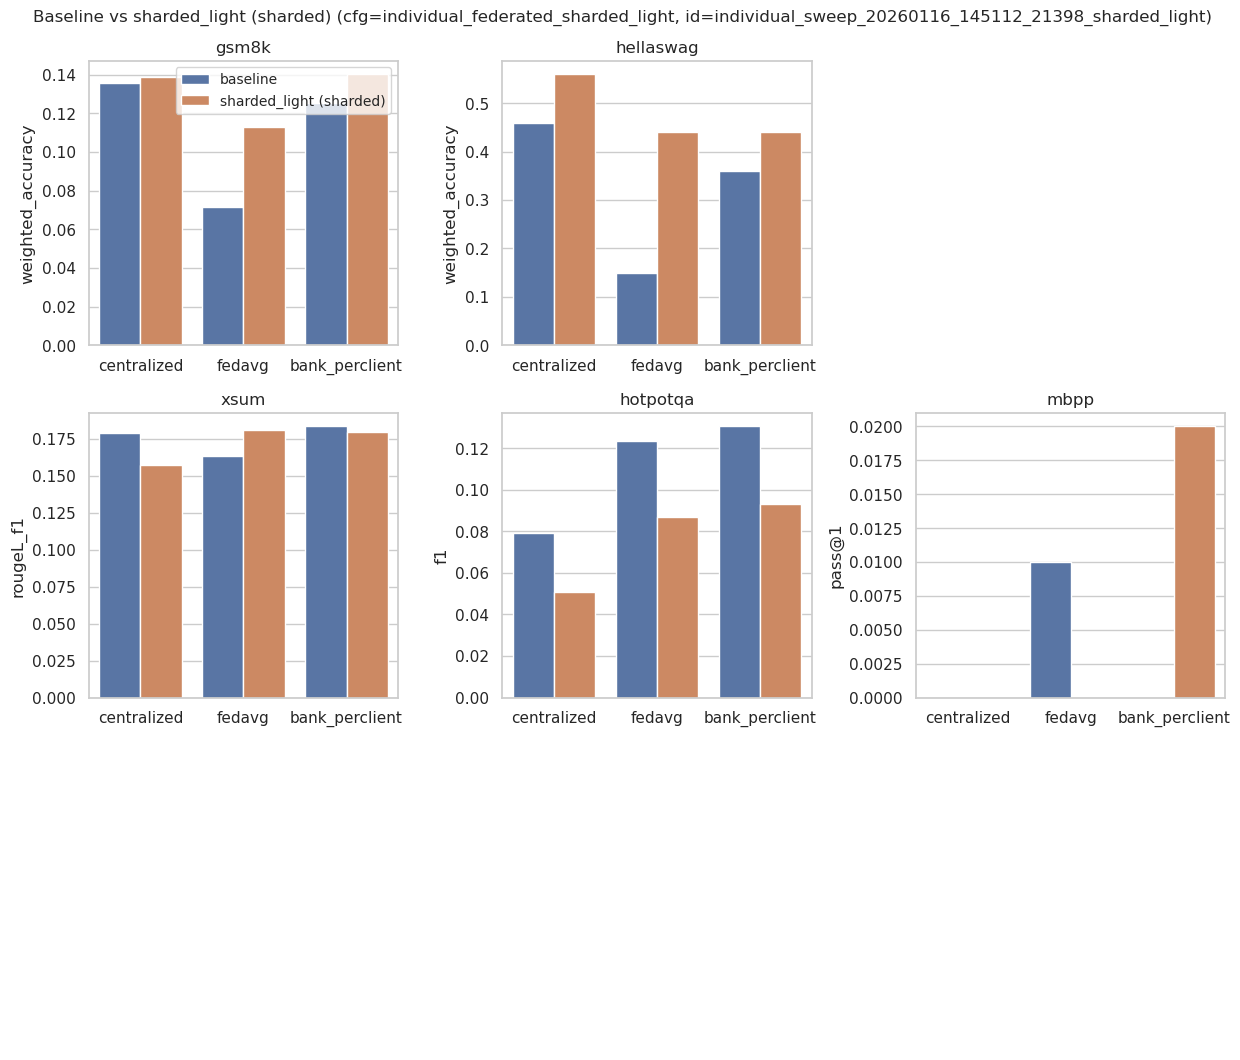

In [4]:
if SWEEP_ID is None:
    print('No sweep runs found in individual_sweep_logs.')
else:
    sweep_dir = SWEEP_LOG_ROOT / SWEEP_ID
    runs_path = sweep_dir / 'runs.tsv'
    if not runs_path.exists():
        print(f'Missing runs.tsv in {sweep_dir}')
    else:
        sweep_runs = pd.read_csv(runs_path, sep='	')
        for row in sweep_runs.itertuples(index=False):
            run_root = (SHARDED_RESULT_ROOT if row.mode == 'sharded' else NORMAL_RESULT_ROOT) / row.run_id
            run_label = f"{row.run_tag} ({row.mode})"
            run_meta = f"cfg={row.cfg_prefix}, id={row.run_id}"
            if not run_root.exists():
                print(f"Missing results dir for {run_label}: {run_root}")
                continue
            run_df = collect_results_df(run_label, run_root)
            plot_run_grid(baseline_df, run_df, run_label, run_meta)


## Rank Sweep Runs

Ranking uses the mean delta across benchmarks:
- delta_bank_fed = bank_perclient - fedavg (primary score)
- delta_fed_drop = centralized - fedavg
- delta_bank_vs_cent = bank_perclient - centralized


In [5]:
if SWEEP_ID is None:
    print('No sweep runs found in individual_sweep_logs.')
else:
    sweep_dir = SWEEP_LOG_ROOT / SWEEP_ID
    runs_path = sweep_dir / 'runs.tsv'
    if not runs_path.exists():
        print(f'Missing runs.tsv in {sweep_dir}')
    else:
        sweep_runs = pd.read_csv(runs_path, sep='	')
        ranking_rows = []
        for row in sweep_runs.itertuples(index=False):
            run_root = (SHARDED_RESULT_ROOT if row.mode == 'sharded' else NORMAL_RESULT_ROOT) / row.run_id
            run_label = f"{row.run_tag} ({row.mode})"
            if not run_root.exists():
                continue
            run_df = collect_results_df(run_label, run_root)
            pivot = run_df.pivot_table(index='benchmark', columns='exp', values='value', aggfunc='first')
            pivot = pivot.dropna(subset=['centralized', 'fedavg', 'bank_perclient'], how='any')
            if pivot.empty:
                continue
            pivot['delta_bank_fed'] = pivot['bank_perclient'] - pivot['fedavg']
            pivot['delta_fed_drop'] = pivot['centralized'] - pivot['fedavg']
            pivot['delta_bank_vs_cent'] = pivot['bank_perclient'] - pivot['centralized']
            ranking_rows.append({
                'run_tag': row.run_tag,
                'mode': row.mode,
                'run_id': row.run_id,
                'cfg_prefix': row.cfg_prefix,
                'benchmarks_used': len(pivot),
                'mean_delta_bank_fed': pivot['delta_bank_fed'].mean(),
                'mean_delta_fed_drop': pivot['delta_fed_drop'].mean(),
                'mean_delta_bank_vs_cent': pivot['delta_bank_vs_cent'].mean(),
            })

        if ranking_rows:
            ranking_df = pd.DataFrame(ranking_rows)
            ranking_df = ranking_df.sort_values('mean_delta_bank_fed', ascending=False)
            display(ranking_df)
        else:
            print('No sweep results available for ranking.')


,run_tag,mode,run_id,cfg_prefix,benchmarks_used,mean_delta_bank_fed,mean_delta_fed_drop,mean_delta_bank_vs_cent
2,sharded_light,sharded,individual_sweep_20260116_145112_21398_sharded...,individual_federated_sharded_light,5,0.010580,0.017266,-0.006686
1,budget,normal,individual_sweep_20260116_145112_21398_budget,individual_federated_budget,5,-0.068267,-0.015426,-0.052841
0,participation,normal,individual_sweep_20260116_145112_21398_partici...,individual_federated_participation,5,-0.078843,-0.000678,-0.078165
